# Comparying the location of isobaths in different runs

In [1]:
import cosima_cookbook as cc
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import xarray as xr
import cmocean as cm
import glob
import matplotlib.colors as col
# need to install opencv-python for this:
import cv2

import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client

figdir = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/figs/'

In [2]:
client = Client(threads_per_worker = 1)

2025-08-21 14:03:25,556 - distributed.nanny - WARNING - Restarting worker
2025-08-21 14:03:25,604 - distributed.nanny - WARNING - Restarting worker
2025-08-21 14:03:25,608 - distributed.nanny - WARNING - Restarting worker
2025-08-21 14:03:25,630 - distributed.nanny - WARNING - Restarting worker
2025-08-21 14:03:25,640 - distributed.nanny - WARNING - Restarting worker
2025-08-21 14:03:25,705 - distributed.nanny - WARNING - Restarting worker
2025-08-21 14:03:25,707 - distributed.nanny - WARNING - Restarting worker
2025-08-21 14:03:25,712 - distributed.nanny - WARNING - Restarting worker
2025-08-21 14:03:25,754 - distributed.nanny - WARNING - Restarting worker
2025-08-21 14:03:25,765 - distributed.nanny - WARNING - Restarting worker
2025-08-21 14:03:25,775 - distributed.nanny - WARNING - Restarting worker
2025-08-21 14:03:25,777 - distributed.nanny - WARNING - Restarting worker
2025-08-21 14:03:25,780 - distributed.nanny - WARNING - Restarting worker
2025-08-21 14:03:25,914 - distributed.

In [6]:
files_dir =  '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/contours/'

#1000m isobaths
panan01_1000m = np.load(files_dir + 'Antarctic_slope_contour_Panan01_1000m.npz')
panan005_1000m = np.load(files_dir + 'Antarctic_slope_contour_Panan005_1000m.npz')
panan0025_1000m = np.load(files_dir + 'Antarctic_slope_contour_Panan0025_1000m.npz')
#2000m isobaths
panan01_2000m = np.load(files_dir + 'Antarctic_slope_contour_Panan01_Smoothedtopography_2000m.npz')
panan005_2000m = np.load(files_dir + 'Antarctic_slope_contour_Panan005_Smoothedtopography_2000m.npz')
panan0025_2000m = np.load(files_dir + 'Antarctic_slope_contour_Panan0025_Smoothedtopography_2000m.npz')
#700m isobaths
panan01_700m = np.load(files_dir + 'Antarctic_slope_contour_Panan01_Smoothedtopography_700m.npz')
panan005_700m = np.load(files_dir + 'Antarctic_slope_contour_Panan005_Smoothedtopography_700m.npz')
panan0025_700m = np.load(files_dir + 'Antarctic_slope_contour_Panan0025_Smoothedtopography_700m.npz')

In [121]:
#importing coords for plotting and visualization
session_p01 = cc.database.create_session('/home/156/wf4500/databases/access/panan01_original_ol01.db')
session_p005 = cc.database.create_session('/home/156/wf4500/databases/access/panan005_final_ol01.db')
session_p0025 = cc.database.create_session('/home/156/wf4500/databases/access/panan0025_final_ol01.db') 

# for panan01
ilat_range_01 = slice(0,panan01_1000m['contour_masked_above'].shape[0])
yh_01 = cc.querying.getvar('panant-01-zstar-ACCESSyr2','yh',session_p01,n=1) #cells centres
yh_01 = yh_01.isel(yh=ilat_range_01)
xh_01 = cc.querying.getvar('panant-01-zstar-ACCESSyr2','xh',session_p01,n=1)  #cells centres
deptho_01 = cc.querying.getvar('panant-01-zstar-ACCESSyr2','deptho',session_p01,n=1).isel(yh=ilat_range_01)

# for panan005
ilat_range_005 = slice(0,panan005_1000m['contour_masked_above'].shape[0])
yh_005 = cc.querying.getvar('panant-005-zstar-ACCESSyr2','yh',session_p005,n=1) #cells centres
yh_005 = yh_005.isel(yh=ilat_range_005)
xh_005 = cc.querying.getvar('panant-005-zstar-ACCESSyr2','xh',session_p005,n=1)  #cells centres
deptho_005 = cc.querying.getvar('panant-005-zstar-ACCESSyr2','deptho',session_p005,n=1).isel(yh=ilat_range_005)

# for panan0025
ilat_range_0025 = slice(0,panan0025_1000m['contour_masked_above'].shape[0])
yh_0025 = cc.querying.getvar('panant-0025-zstar-ACCESSyr2','yh',session_p0025,n=1) #cells centres
yh_0025 = yh_0025.isel(yh=ilat_range_0025)
xh_0025 = cc.querying.getvar('panant-0025-zstar-ACCESSyr2','xh',session_p0025,n=1)  #cells centres
deptho_0025 = cc.querying.getvar('panant-0025-zstar-ACCESSyr2','deptho',session_p0025,n=1).isel(yh=ilat_range_0025)

I also want to extract latitudes along the isobath for checking how far they are

**First the 1000 m isobath cases**

In [176]:
#latitude and longitude extraction for panan01 - 1000 m isobath
lat2d_01 = ((deptho_01*0)+1)*deptho_01.yh; lon2d_01 = ((deptho_01*0)+1)*deptho_01.xh #creating 2d matrices for lon and lat
lat2d_01 = lat2d_01.where(panan01_1000m['contour_masked_above']>0);lon2d_01 = lon2d_01.where(panan01_1000m['contour_masked_above']>0)
lat_contour_01 = lat2d_01.stack(contour_index={'xh','yh'}).dropna('contour_index').compute()
lat_contour_01.name= 'lat_along_contour'
lon_contour_01 = lon2d_01.stack(contour_index={'xh','yh'}).dropna('contour_index').compute()
lon_contour_01.name= 'lon_along_contour'
coords_along_1000contour_01 = xr.merge([lon_contour_01,lat_contour_01]).sortby('lon_along_contour')

#latitude and longitude extraction for panan005 - 1000 m isobath
lat2d_005 = ((deptho_005*0)+1)*deptho_005.yh; lon2d_005 = ((deptho_005*0)+1)*deptho_005.xh #creating 2d matrices for lon and lat
lat2d_005 = lat2d_005.where(panan005_1000m['contour_masked_above']>0);lon2d_005 = lon2d_005.where(panan005_1000m['contour_masked_above']>0)
lat_contour_005 = lat2d_005.stack(contour_index={'xh','yh'}).dropna('contour_index').compute()
lat_contour_005.name= 'lat_along_contour'
lon_contour_005 = lon2d_005.stack(contour_index={'xh','yh'}).dropna('contour_index').compute()
lon_contour_005.name= 'lon_along_contour'
coords_along_1000contour_005 = xr.merge([lon_contour_005,lat_contour_005]).sortby('lon_along_contour')


#latitude and longitude extraction for panan0025 - 1000 m isobath
lat2d_0025 = ((deptho_0025*0)+1)*deptho_0025.yh; lon2d_0025 = ((deptho_0025*0)+1)*deptho_0025.xh #creating 2d matrices for lon and lat
lat2d_0025 = lat2d_0025.where(panan0025_1000m['contour_masked_above']>0);lon2d_0025 = lon2d_0025.where(panan0025_1000m['contour_masked_above']>0)
lat_contour_0025 = lat2d_0025.stack(contour_index={'xh','yh'}).dropna('contour_index').compute()
lat_contour_0025.name= 'lat_along_contour'
lon_contour_0025 = lon2d_0025.stack(contour_index={'xh','yh'}).dropna('contour_index').compute()
lon_contour_0025.name= 'lon_along_contour'
coords_along_1000contour_0025 = xr.merge([lon_contour_0025,lat_contour_0025]).sortby('lon_along_contour')

**Second the 700 m isobath cases**

In [177]:
#latitude and longitude extraction for panan01 - 700 m isobath
lat2d_01 = ((deptho_01*0)+1)*deptho_01.yh; lon2d_01 = ((deptho_01*0)+1)*deptho_01.xh #creating 2d matrices for lon and lat
lat2d_01 = lat2d_01.where(panan01_700m['contour_masked_above']>0);lon2d_01 = lon2d_01.where(panan01_700m['contour_masked_above']>0)
lat_contour_01 = lat2d_01.stack(contour_index={'xh','yh'}).dropna('contour_index').compute()
lat_contour_01.name= 'lat_along_contour'
lon_contour_01 = lon2d_01.stack(contour_index={'xh','yh'}).dropna('contour_index').compute()
lon_contour_01.name= 'lon_along_contour'
coords_along_700contour_01 = xr.merge([lon_contour_01,lat_contour_01]).sortby('lon_along_contour')

#latitude and longitude extraction for panan005 - 700 m isobath
lat2d_005 = ((deptho_005*0)+1)*deptho_005.yh; lon2d_005 = ((deptho_005*0)+1)*deptho_005.xh #creating 2d matrices for lon and lat
lat2d_005 = lat2d_005.where(panan005_700m['contour_masked_above']>0);lon2d_005 = lon2d_005.where(panan005_700m['contour_masked_above']>0)
lat_contour_005 = lat2d_005.stack(contour_index={'xh','yh'}).dropna('contour_index').compute()
lat_contour_005.name= 'lat_along_contour'
lon_contour_005 = lon2d_005.stack(contour_index={'xh','yh'}).dropna('contour_index').compute()
lon_contour_005.name= 'lon_along_contour'
coords_along_700contour_005 = xr.merge([lon_contour_005,lat_contour_005]).sortby('lon_along_contour')


#latitude and longitude extraction for panan0025 - 700 m isobath
lat2d_0025 = ((deptho_0025*0)+1)*deptho_0025.yh; lon2d_0025 = ((deptho_0025*0)+1)*deptho_0025.xh #creating 2d matrices for lon and lat
lat2d_0025 = lat2d_0025.where(panan0025_700m['contour_masked_above']>0);lon2d_0025 = lon2d_0025.where(panan0025_700m['contour_masked_above']>0)
lat_contour_0025 = lat2d_0025.stack(contour_index={'xh','yh'}).dropna('contour_index').compute()
lat_contour_0025.name= 'lat_along_contour'
lon_contour_0025 = lon2d_0025.stack(contour_index={'xh','yh'}).dropna('contour_index').compute()
lon_contour_0025.name= 'lon_along_contour'
coords_along_700contour_0025 = xr.merge([lon_contour_0025,lat_contour_0025]).sortby('lon_along_contour')

**Third the 2000 m isobath cases**

In [178]:
#latitude and longitude extraction for panan01 - 2000 m isobath
lat2d_01 = ((deptho_01*0)+1)*deptho_01.yh; lon2d_01 = ((deptho_01*0)+1)*deptho_01.xh #creating 2d matrices for lon and lat
lat2d_01 = lat2d_01.where(panan01_2000m['contour_masked_above']>0);lon2d_01 = lon2d_01.where(panan01_2000m['contour_masked_above']>0)
lat_contour_01 = lat2d_01.stack(contour_index={'xh','yh'}).dropna('contour_index').compute()
lat_contour_01.name= 'lat_along_contour'
lon_contour_01 = lon2d_01.stack(contour_index={'xh','yh'}).dropna('contour_index').compute()
lon_contour_01.name= 'lon_along_contour'
coords_along_2000contour_01 = xr.merge([lon_contour_01,lat_contour_01]).sortby('lon_along_contour')

#latitude and longitude extraction for panan005 - 2000 m isobath
lat2d_005 = ((deptho_005*0)+1)*deptho_005.yh; lon2d_005 = ((deptho_005*0)+1)*deptho_005.xh #creating 2d matrices for lon and lat
lat2d_005 = lat2d_005.where(panan005_2000m['contour_masked_above']>0);lon2d_005 = lon2d_005.where(panan005_2000m['contour_masked_above']>0)
lat_contour_005 = lat2d_005.stack(contour_index={'xh','yh'}).dropna('contour_index').compute()
lat_contour_005.name= 'lat_along_contour'
lon_contour_005 = lon2d_005.stack(contour_index={'xh','yh'}).dropna('contour_index').compute()
lon_contour_005.name= 'lon_along_contour'
coords_along_2000contour_005 = xr.merge([lon_contour_005,lat_contour_005]).sortby('lon_along_contour')


#latitude and longitude extraction for panan0025 - 2000 m isobath
lat2d_0025 = ((deptho_0025*0)+1)*deptho_0025.yh; lon2d_0025 = ((deptho_0025*0)+1)*deptho_0025.xh #creating 2d matrices for lon and lat
lat2d_0025 = lat2d_0025.where(panan0025_2000m['contour_masked_above']>0);lon2d_0025 = lon2d_0025.where(panan0025_2000m['contour_masked_above']>0)
lat_contour_0025 = lat2d_0025.stack(contour_index={'xh','yh'}).dropna('contour_index').compute()
lat_contour_0025.name= 'lat_along_contour'
lon_contour_0025 = lon2d_0025.stack(contour_index={'xh','yh'}).dropna('contour_index').compute()
lon_contour_0025.name= 'lon_along_contour'
coords_along_2000contour_0025 = xr.merge([lon_contour_0025,lat_contour_0025]).sortby('lon_along_contour')

To evaluate the latitude distance bewtween isobaths, I first need to bin longs along isobath within a commong lat/lon framework. let's bin them into 3 degree bins, as this is commonly used in our heat transport calculations

In [215]:
#setting the bin edges and centres
bin_edges= np.arange(-280,83,3)
bin_centres = (bin_edges[1:]+bin_edges[:-1])/2

#binning panan-01
coords_along_1000contour_01_3deg = coords_along_1000contour_01.groupby_bins('lon_along_contour',bins = bin_edges).mean()
coords_along_1000contour_01_3deg['lon_along_contour_bins'] = bin_centres
coords_along_2000contour_01_3deg = coords_along_2000contour_01.groupby_bins('lon_along_contour',bins = bin_edges).mean()
coords_along_2000contour_01_3deg['lon_along_contour_bins'] = bin_centres
coords_along_700contour_01_3deg = coords_along_700contour_01.groupby_bins('lon_along_contour',bins = bin_edges).mean()
coords_along_700contour_01_3deg['lon_along_contour_bins'] = bin_centres

#binning panan-005
coords_along_1000contour_005_3deg = coords_along_1000contour_005.groupby_bins('lon_along_contour',bins = bin_edges).mean()
coords_along_1000contour_005_3deg['lon_along_contour_bins'] = bin_centres
coords_along_2000contour_005_3deg = coords_along_2000contour_005.groupby_bins('lon_along_contour',bins = bin_edges).mean()
coords_along_2000contour_005_3deg['lon_along_contour_bins'] = bin_centres
coords_along_700contour_005_3deg = coords_along_700contour_005.groupby_bins('lon_along_contour',bins = bin_edges).mean()
coords_along_700contour_005_3deg['lon_along_contour_bins'] = bin_centres

#binning panan-0025
coords_along_1000contour_0025_3deg = coords_along_1000contour_0025.groupby_bins('lon_along_contour',bins = bin_edges).mean()
coords_along_1000contour_0025_3deg['lon_along_contour_bins'] = bin_centres
coords_along_2000contour_0025_3deg = coords_along_2000contour_0025.groupby_bins('lon_along_contour',bins = bin_edges).mean()
coords_along_2000contour_0025_3deg['lon_along_contour_bins'] = bin_centres
coords_along_700contour_0025_3deg = coords_along_700contour_0025.groupby_bins('lon_along_contour',bins = bin_edges).mean()
coords_along_700contour_0025_3deg['lon_along_contour_bins'] = bin_centres


## Comparisson between isobaths in the same resolution case


**Panan01**

Text(0, 0.5, 'Latitude difference')

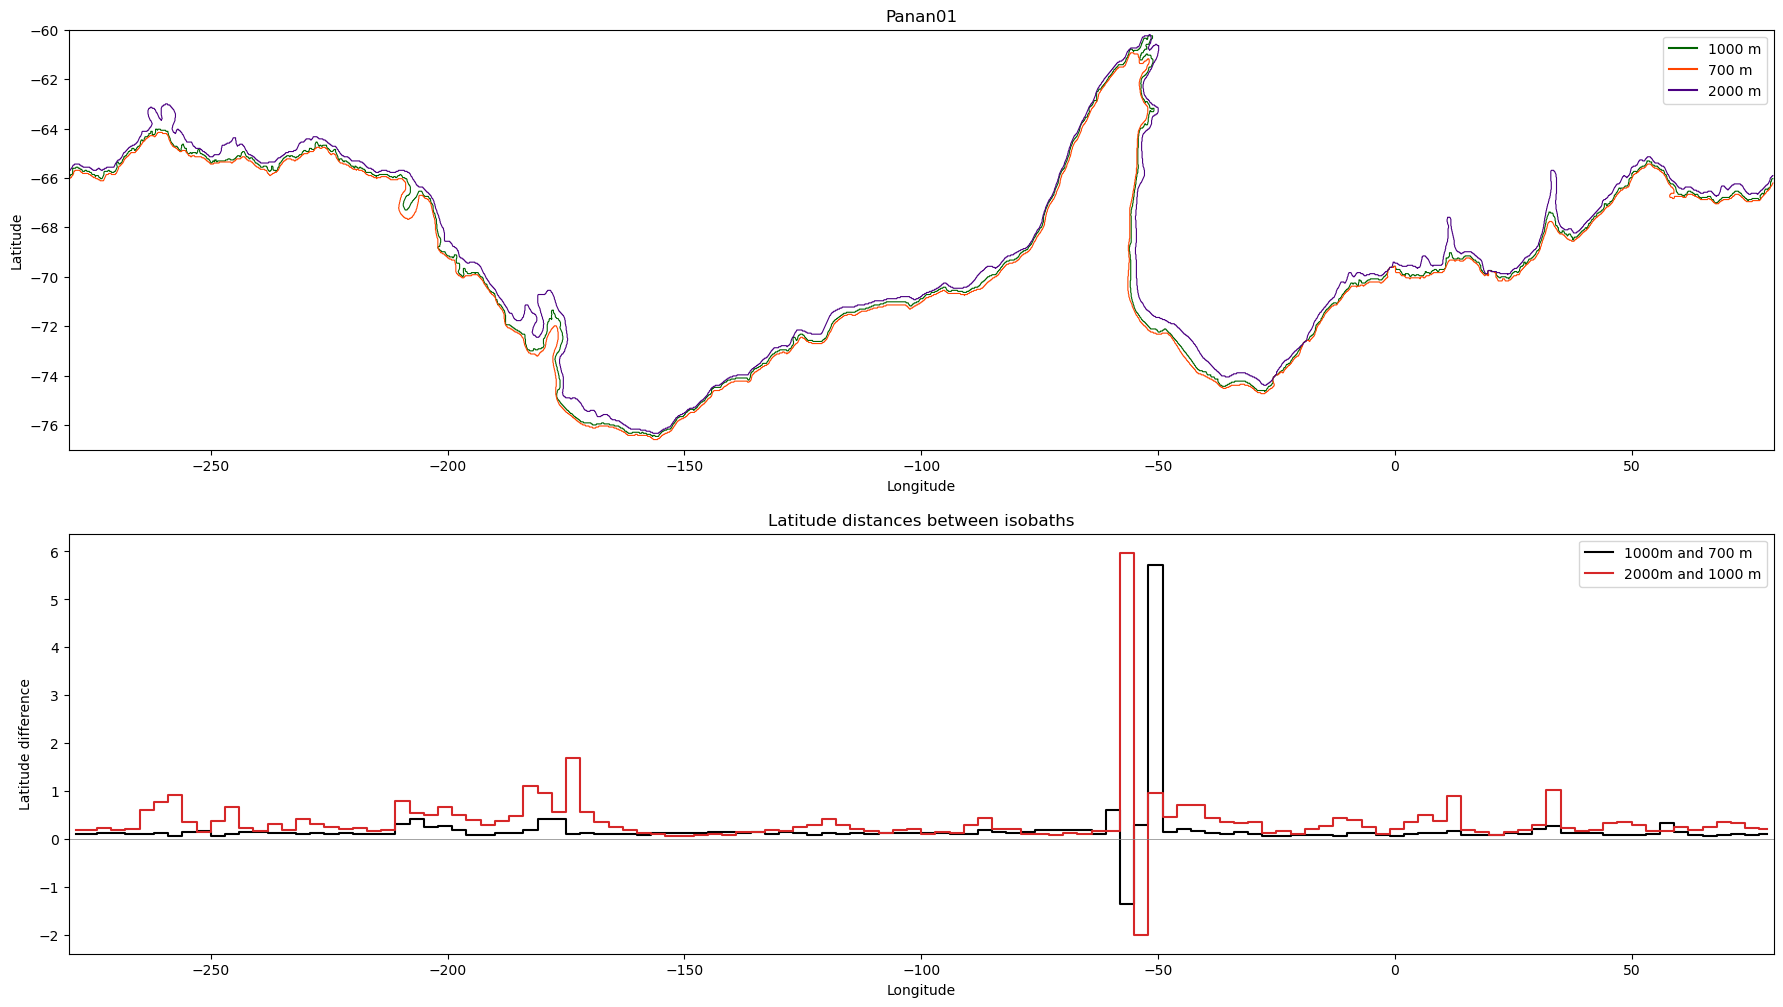

In [221]:
plt.figure(figsize=(22,12))
linewidth_isobath=.8

plt.subplot(2,1,1)
plt.contour(xh_01,yh_01,np.where(panan01_1000m['contour_masked_above']>0,(panan01_1000m['contour_masked_above']*0)+1,-panan01_1000m['contour_masked_above']),levels=[1,],colors='darkgreen',linewidths=linewidth_isobath); plt.plot(-290,-70,color='darkgreen',label='1000 m')
plt.contour(xh_01,yh_01,np.where(panan01_700m['contour_masked_above']>0,(panan01_700m['contour_masked_above']*0)+1,-panan01_700m['contour_masked_above']),levels=[1,],colors='orangered',linewidths=linewidth_isobath); plt.plot(-290,-70,color='orangered',label='700 m')
plt.contour(xh_01,yh_01,np.where(panan01_2000m['contour_masked_above']>0,(panan01_2000m['contour_masked_above']*0)+1,-panan01_2000m['contour_masked_above']),levels=[1,],colors='indigo',linewidths=linewidth_isobath); plt.plot(-290,-70,color='indigo',label='2000 m')
plt.title('Panan01')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(-280,80)
plt.ylim(-77,-60)
plt.legend()

plt.subplot(2,1,2)
plt.step(bin_centres,coords_along_1000contour_01_3deg.lat_along_contour - coords_along_700contour_01_3deg.lat_along_contour,where='mid',color='black',label='1000m and 700 m')
plt.step(bin_centres,coords_along_2000contour_01_3deg.lat_along_contour - coords_along_1000contour_01_3deg.lat_along_contour,where='mid',color='tab:red',label='2000m and 1000 m')
plt.plot([-280,80],[0,0],color='grey',linewidth=-.5)
plt.xlim(-280,80)
#plt.ylim(-1,1)
plt.title('Latitude distances between isobaths')
plt.legend()
plt.xlabel('Longitude')
plt.ylabel('Latitude difference')


**Panan005**

Text(0, 0.5, 'Latitude difference')

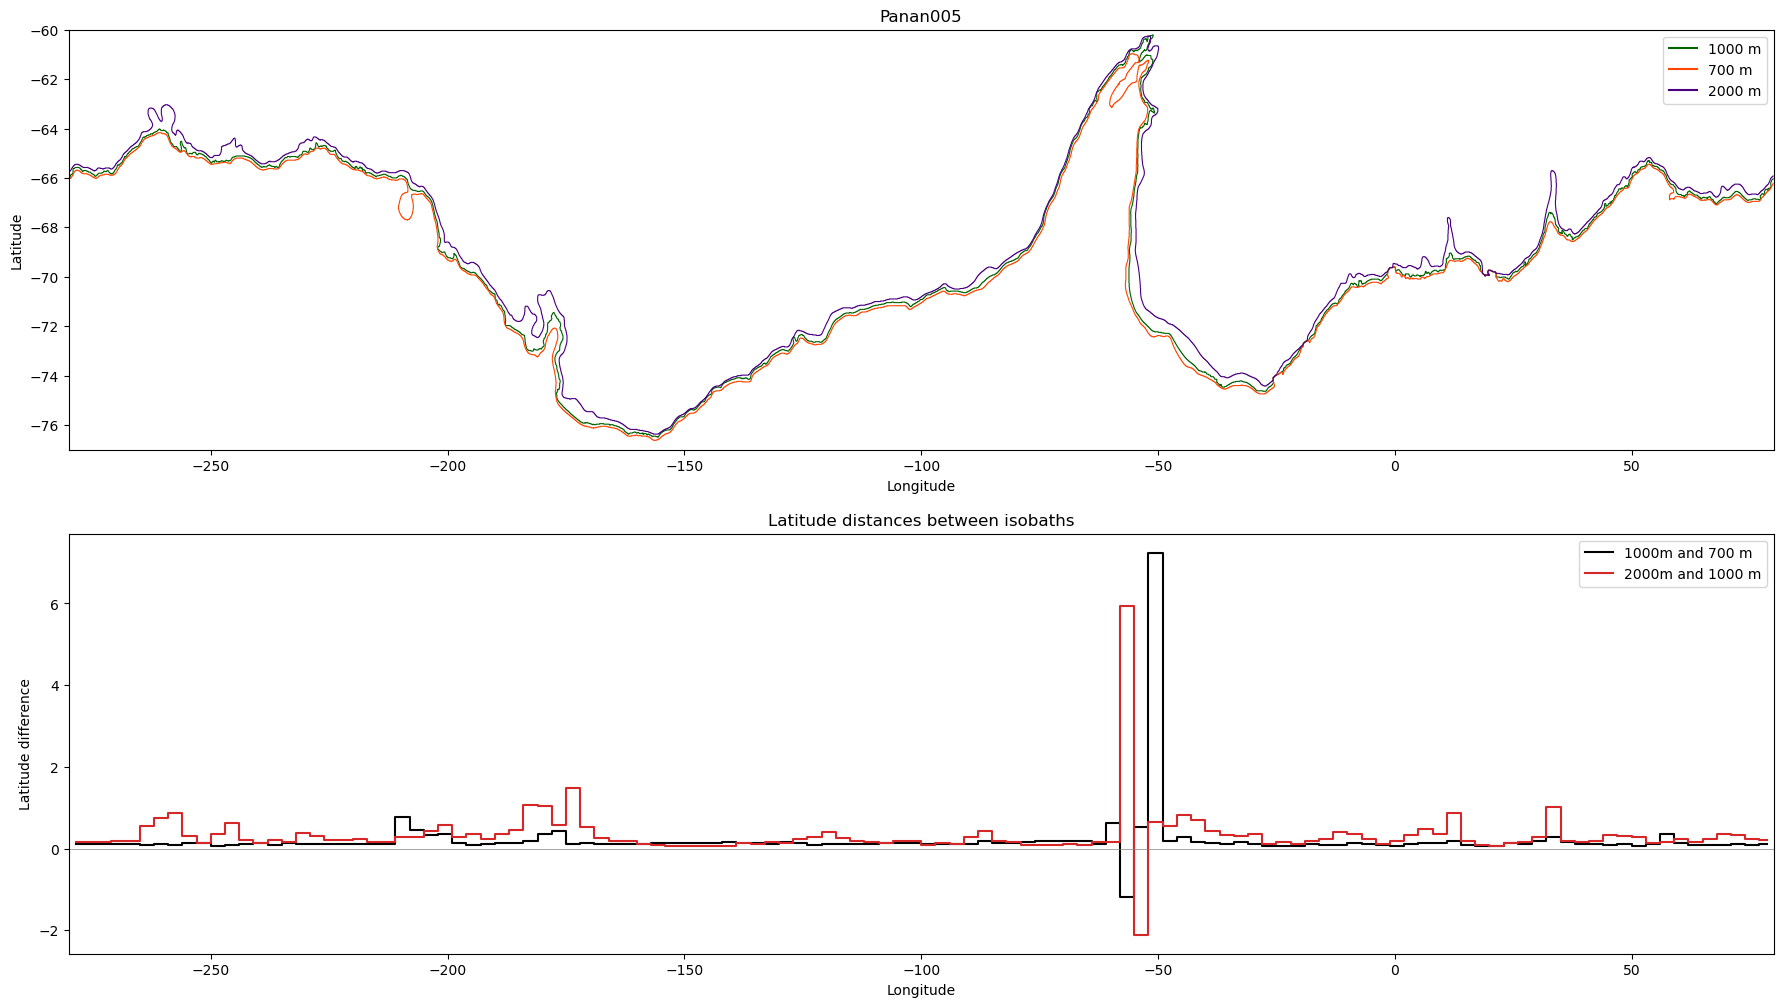

In [222]:
plt.figure(figsize=(22,12))
linewidth_isobath=.8

plt.subplot(2,1,1)
plt.contour(xh_005,yh_005,np.where(panan005_1000m['contour_masked_above']>0,(panan005_1000m['contour_masked_above']*0)+1,-panan005_1000m['contour_masked_above']),levels=[1,],colors='darkgreen',linewidths=linewidth_isobath); plt.plot(-290,-70,color='darkgreen',label='1000 m')
plt.contour(xh_005,yh_005,np.where(panan005_700m['contour_masked_above']>0,(panan005_700m['contour_masked_above']*0)+1,-panan005_700m['contour_masked_above']),levels=[1,],colors='orangered',linewidths=linewidth_isobath); plt.plot(-290,-70,color='orangered',label='700 m')
plt.contour(xh_005,yh_005,np.where(panan005_2000m['contour_masked_above']>0,(panan005_2000m['contour_masked_above']*0)+1,-panan005_2000m['contour_masked_above']),levels=[1,],colors='indigo',linewidths=linewidth_isobath); plt.plot(-290,-70,color='indigo',label='2000 m')
plt.title('Panan005')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(-280,80)
plt.ylim(-77,-60)
plt.legend()

plt.subplot(2,1,2)
plt.step(bin_centres,coords_along_1000contour_005_3deg.lat_along_contour - coords_along_700contour_005_3deg.lat_along_contour,where='mid',color='black',label='1000m and 700 m')
plt.step(bin_centres,coords_along_2000contour_005_3deg.lat_along_contour - coords_along_1000contour_005_3deg.lat_along_contour,where='mid',color='tab:red',label='2000m and 1000 m')
plt.plot([-280,80],[0,0],color='grey',linewidth=-.5)
plt.xlim(-280,80)
#plt.ylim(-1,1)
plt.title('Latitude distances between isobaths')
plt.legend()
plt.xlabel('Longitude')
plt.ylabel('Latitude difference')

**panan0025**

Text(0, 0.5, 'Latitude difference')

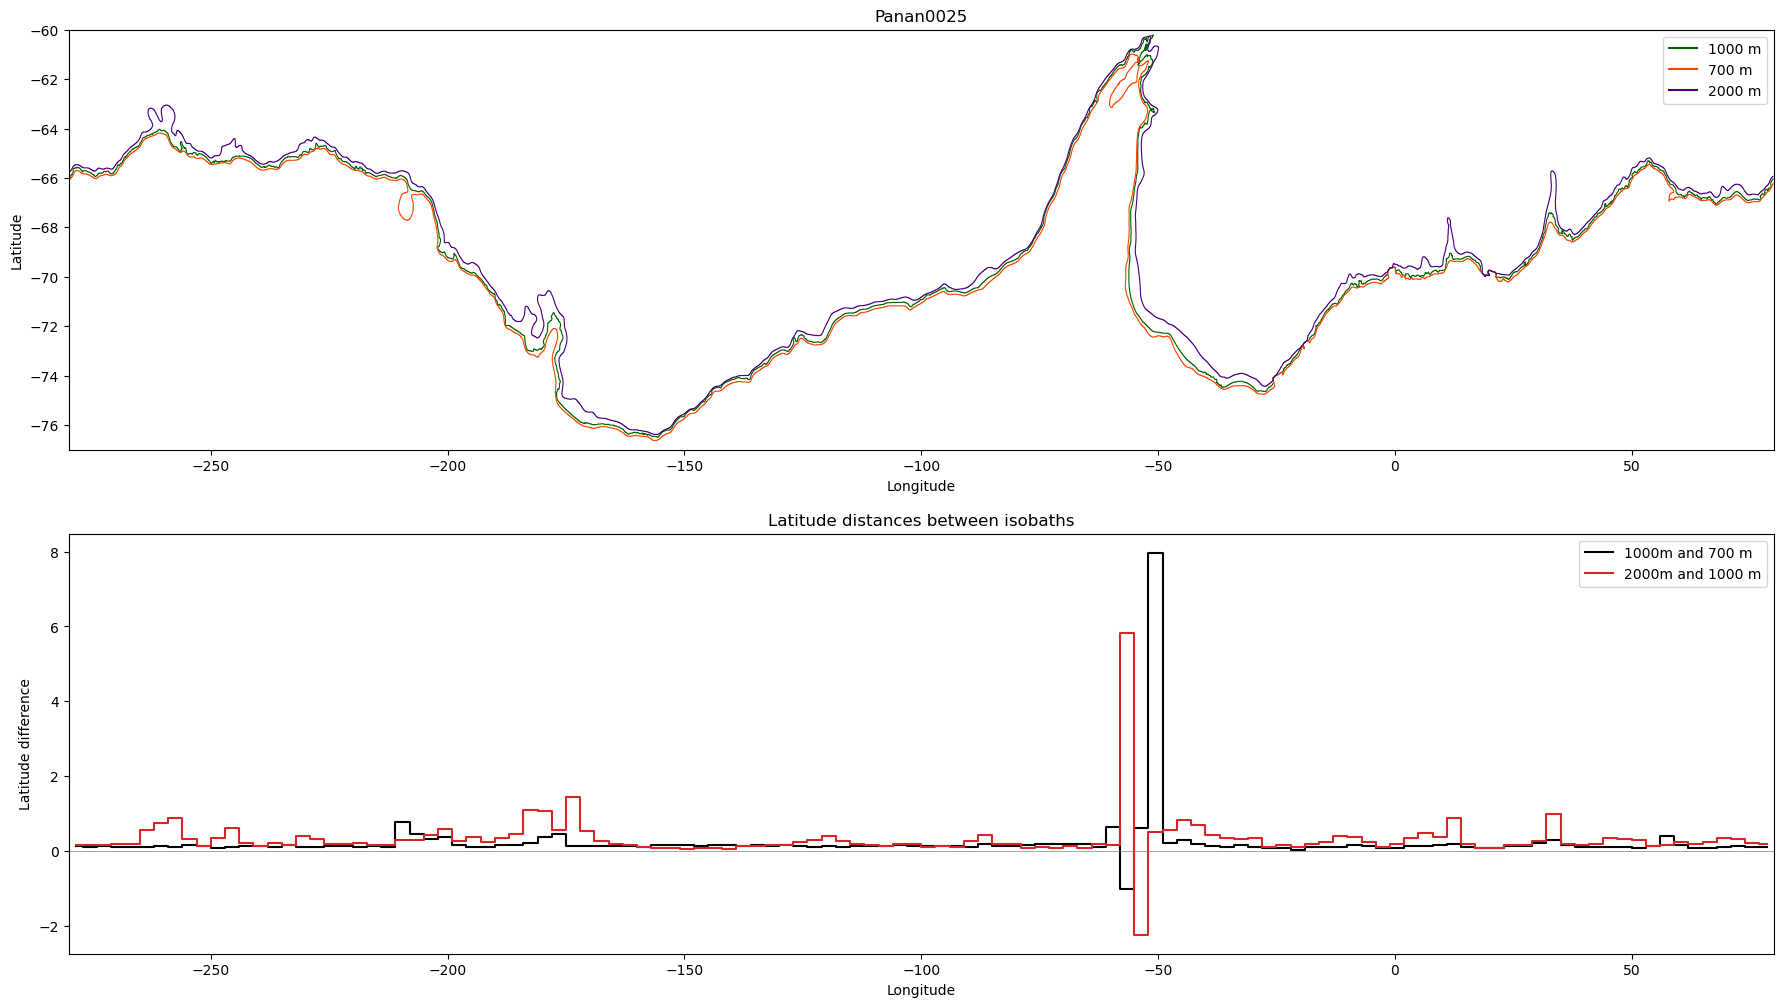

In [223]:
plt.figure(figsize=(22,12))
linewidth_isobath=.8

plt.subplot(2,1,1)
plt.contour(xh_0025,yh_0025,np.where(panan0025_1000m['contour_masked_above']>0,(panan0025_1000m['contour_masked_above']*0)+1,-panan0025_1000m['contour_masked_above']),levels=[1,],colors='darkgreen',linewidths=linewidth_isobath); plt.plot(-290,-70,color='darkgreen',label='1000 m')
plt.contour(xh_0025,yh_0025,np.where(panan0025_700m['contour_masked_above']>0,(panan0025_700m['contour_masked_above']*0)+1,-panan0025_700m['contour_masked_above']),levels=[1,],colors='orangered',linewidths=linewidth_isobath); plt.plot(-290,-70,color='orangered',label='700 m')
plt.contour(xh_0025,yh_0025,np.where(panan0025_2000m['contour_masked_above']>0,(panan0025_2000m['contour_masked_above']*0)+1,-panan0025_2000m['contour_masked_above']),levels=[1,],colors='indigo',linewidths=linewidth_isobath); plt.plot(-290,-70,color='indigo',label='2000 m')
plt.title('Panan0025')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(-280,80)
plt.ylim(-77,-60)
plt.legend()

plt.subplot(2,1,2)
plt.step(bin_centres,coords_along_1000contour_0025_3deg.lat_along_contour - coords_along_700contour_0025_3deg.lat_along_contour,where='mid',color='black',label='1000m and 700 m')
plt.step(bin_centres,coords_along_2000contour_0025_3deg.lat_along_contour - coords_along_1000contour_0025_3deg.lat_along_contour,where='mid',color='tab:red',label='2000m and 1000 m')
plt.plot([-280,80],[0,0],color='grey',linewidth=-.5)
plt.xlim(-280,80)
#plt.ylim(-1,1)
plt.title('Latitude distances between isobaths')
plt.legend()
plt.xlabel('Longitude')
plt.ylabel('Latitude difference')

In general, the deeper isobath seem to be roughly north of the shallower isobath. Also the changes between isobath shapes seem t be consistent across simulations. So on that side I'm happy. Perhaps not that happy on the wigglyness of some of the isobaths -THo the zonal cnvergence should get rid of them
